### Importing Libraries



In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score


### Reading CSV file

In [2]:
df = pd.read_csv("../Datasets/diabetes.csv")

### Data Preprocessing

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Splitting Our data to X and Y

In [7]:
X = df.drop(columns=["Outcome"]).to_numpy()
Y = df["Outcome"].to_numpy().reshape(-1,1)
print(f"Shape of X is {X.shape}")
print(f"Shape of Y is {Y.shape}")
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    train_size=0.8,
    stratify=Y
)

Y_train = Y_train.reshape(-1,1)
Y_test = Y_test.reshape(-1,1)


Shape of X is (768, 8)
Shape of Y is (768, 1)


### Feature Scaling (Standardization)
We just use training Data for that to avoid Data Leakage

In [8]:
X_train_mean = np.mean(X_train, axis=0,keepdims=True)
X_train_std = np.std(X_train,axis=0,keepdims=True)
X_train_norm = (X_train - X_train_mean)/X_train_std
X_test_norm = (X_test - X_train_mean)/X_train_std


In [9]:
print(X.shape[0])

768


### Initializing Random Weights

In [10]:
W = np.random.randn(X_train.shape[1],1)
b = 0
print(W)

[[-1.47419808]
 [ 0.344114  ]
 [ 0.03661986]
 [-0.31849384]
 [ 0.1825002 ]
 [ 0.51102985]
 [ 1.04614459]
 [ 0.33306174]]


### Cost Function — Log Loss

For Binary Logistic Regression, we use **Log Loss**, also called **Binary Cross-Entropy (BCE)**.

The cost function is:

$$
J(W,b) =
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

Where:

- $n$ = number of training samples
- $y_i$ = actual class label, either $0$ or $1$
- $\hat{y}_i$ = predicted probability from the sigmoid function
- $W$ = weights
- $b$ = bias

If the actual class is $1$:

$$
Loss = -\log(\hat{y})
$$

If the actual class is $0$:

$$
Loss = -\log(1-\hat{y})
$$

Log Loss gives a large penalty when the model is confidently wrong and a small loss when the predicted probability is close to the correct class.

In [11]:
def bce(Y, Y_hat):
    n = len(Y)

    eps = 1e-15
    Y_hat = np.clip(Y_hat, eps, 1 - eps)

    return -np.sum(
        Y * np.log(Y_hat) +
        (1 - Y) * np.log(1 - Y_hat)
    ) / n

### Sigmoid Function

In [12]:
def sigmoid(Y_hat):
    return 1/(1 + np.exp(- Y_hat))


### Predict Function

In [13]:
def predict(W,X,b):
     z = X@W + b
     return sigmoid(z)


### Applying Gradient Descent

In [14]:
def dEdw(X,Y,W,b):
    Y_hat = predict(W, X, b)
    m = len(Y)
    error = Y_hat -Y
    rv = (X.T @ error ) / m
    return rv

def dEdb(X, Y, W,b):
    Y_hat = predict(W, X, b)

    m = len(Y)
    return np.sum(Y_hat - Y) / m


### Train Function

In [15]:
def train(X, Y, W, b, learning_rate = 0.1, num_iter = 1000):
    losses = []
    for i in range(num_iter):
        dw =  dEdw(X,Y,W,b)
        db =  dEdb(X,Y, W, b)
        #  we are initializing after calculating in db we are passing W also that may be problematic
        W = W - learning_rate *dw
        b = b - learning_rate * db

        Y_hat = predict(W, X, b)

        loss = bce(Y,Y_hat)
        losses.append(loss)
        print(f"Loss after iteration {i} is {loss}")
    return W,b,losses

W,b, losses = train(X_train_norm, Y_train, W, b)


Loss after iteration 0 is 0.871667047909849
Loss after iteration 1 is 0.8521874098968252
Loss after iteration 2 is 0.833937396586458
Loss after iteration 3 is 0.8168252149736087
Loss after iteration 4 is 0.8007654462950267
Loss after iteration 5 is 0.7856789517390935
Loss after iteration 6 is 0.7714926559147439
Loss after iteration 7 is 0.7581392506157583
Loss after iteration 8 is 0.7455568515168869
Loss after iteration 9 is 0.7336886319465091
Loss after iteration 10 is 0.722482450972281
Loss after iteration 11 is 0.7118904876386546
Loss after iteration 12 is 0.7018688891145618
Loss after iteration 13 is 0.6923774375108595
Loss after iteration 14 is 0.6833792379805669
Loss after iteration 15 is 0.6748404292177079
Loss after iteration 16 is 0.6667299164552382
Loss after iteration 17 is 0.6590191263969845
Loss after iteration 18 is 0.6516817831019407
Loss after iteration 19 is 0.644693703596821
Loss after iteration 20 is 0.6380326118699594
Loss after iteration 21 is 0.6316779698576284
Lo

In [16]:
Y_hat_test = predict(W,X_test_norm,b)

Y_test_pred = (Y_hat_test >= 0.5).astype(int)

In [17]:
Y_test_pred


array([[0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
    

In [18]:
Y_test_pred = Y_test_pred.ravel()
Y_test = Y_test.ravel()

In [19]:
print(confusion_matrix(Y_test, Y_test_pred))
print("Accuracy :", accuracy_score(Y_test, Y_test_pred))
print("Precision:", precision_score(Y_test, Y_test_pred))
print("Recall   :", recall_score(Y_test, Y_test_pred))
print("F1 Score :", f1_score(Y_test, Y_test_pred))

[[86 14]
 [24 30]]
Accuracy : 0.7532467532467533
Precision: 0.6818181818181818
Recall   : 0.5555555555555556
F1 Score : 0.6122448979591837


In [20]:


# sklearn expects:
# X = (samples, features)

X_train_sk = X_train_norm
X_test_sk = X_test_norm

Y_train_sk = Y_train.ravel()
Y_test_sk = Y_test.ravel()

model = LogisticRegression()

model.fit(X_train_sk, Y_train_sk)

Y_pred_sk = model.predict(X_test_sk)

print("Confusion Matrix:")
print(confusion_matrix(Y_test_sk, Y_pred_sk))

print("Accuracy :", accuracy_score(Y_test_sk, Y_pred_sk))
print("Precision:", precision_score(Y_test_sk, Y_pred_sk))
print("Recall   :", recall_score(Y_test_sk, Y_pred_sk))
print("F1 Score :", f1_score(Y_test_sk, Y_pred_sk))

NameError: name 'LogisticRegression' is not defined

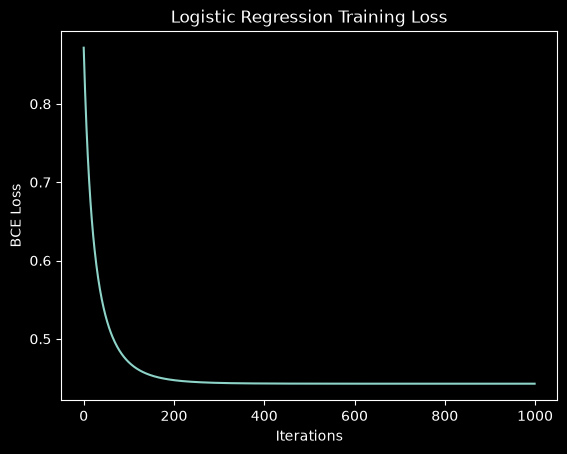

In [21]:
import matplotlib.pyplot as plt

plt.plot(losses)

plt.xlabel("Iterations")
plt.ylabel("BCE Loss")
plt.title("Logistic Regression Training Loss")

plt.show()

### Regularized Logistic Regression Importing classes

In [54]:
from RegularizedLogisticRegression.L1LogRegression import L1LogisticRegression
model = L1LogisticRegression()
model.fit(X_train_norm, Y_train)


ModuleNotFoundError: No module named 'RegularizedLogisticRegression'

In [24]:
Y_hat = model.predict(X_test_norm)
Y_test_pred = (Y_hat >= 0.5).astype(int)
print("Accuracy : " , accuracy_score(Y_test.ravel(), Y_test_pred.ravel()))

Accuracy :  0.7532467532467533


In [46]:
from LogisticRegression import L2LogisticRegression
model = L2LogisticRegression()
model.fit(X_train_norm, Y_train)

Loss after epoch 0 is 1.166824222698611
Loss after epoch 50 is 0.6675831151673942
Loss after epoch 100 is 0.52179869483183
Loss after epoch 150 is 0.471495348243138
Loss after epoch 200 is 0.4544025694219173
Loss after epoch 250 is 0.4484038702991071
Loss after epoch 300 is 0.44608836921809825
Loss after epoch 350 is 0.4450904841339413
Loss after epoch 400 is 0.4446219661346334
Loss after epoch 450 is 0.4443897540026715
Loss after epoch 499 is 0.44427268822965255


In [37]:
model.W

array([[ 0.37102553],
       [ 0.90273229],
       [-0.0471006 ],
       [ 0.27941744],
       [ 0.47493341],
       [ 0.53327485],
       [ 0.1992645 ],
       [ 0.14024392]])

In [47]:
from LogisticRegression import L1LogisticRegression
model1 = L1LogisticRegression()
model1.fit(X_train_norm, Y_train)

Loss after epoch 0 is 0.9061304911768744
Loss after epoch 50 is 0.584360600445606
Loss after epoch 100 is 0.510810213304375
Loss after epoch 150 is 0.4848948880938223
Loss after epoch 200 is 0.47331858706802576
Loss after epoch 250 is 0.4670393779062516
Loss after epoch 300 is 0.4633506417411297
Loss after epoch 350 is 0.4610772799774255
Loss after epoch 400 is 0.4596302793628577
Loss after epoch 450 is 0.45868719902859517
Loss after epoch 500 is 0.4580612626167482
Loss after epoch 550 is 0.45763984264629387
Loss after epoch 600 is 0.45735288142928865
Loss after epoch 650 is 0.4571556954531381
Loss after epoch 700 is 0.45701919620641474
Loss after epoch 750 is 0.4569241294074013
Loss after epoch 800 is 0.4568575774697003
Loss after epoch 850 is 0.4568107795653391
Loss after epoch 900 is 0.45677774181765124
Loss after epoch 950 is 0.4567543341202424
Loss after epoch 999 is 0.45673797433584157


In [48]:
Y_predict = model1.predict(X_test_norm)

In [49]:
Y_test_pred = (Y_predict >= 0.3).astype(int)
print("Accuracy : " , accuracy_score(Y_test.ravel(), Y_test_pred.ravel()))

Accuracy :  0.7662337662337663
